<div align='center'>
<u>Marketing Uplift modeling - Kaggle</u>

**_Kaggle Criteo AI Lab data_**

**Author**: _Karteek Pradyumna Bulusu_ <br>
Date: 2026-10-05 <br><br>

</div>

- Import libraries and set pandas display options.


In [2]:
!pip install -q causalml

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pd.set_option("display.precision", 4)
import kagglehub
import os
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier, XGBRegressor
from causalml.inference.meta import BaseTClassifier, BaseXClassifier
from causalml.metrics import qini_score, plot_qini
from sklearn.metrics import roc_auc_score

/Users/karteekpbulusu/Documents/KB_DataScience/Kaggle_Marketing_Uplift_Modeling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data load

- Download the Criteo uplift dataset from Kaggle.


In [4]:
# Download latest version
path = kagglehub.dataset_download("arashnic/uplift-modeling")
files = os.listdir(path)
print("Path to dataset files:", path)

Path to dataset files: /Users/karteekpbulusu/.cache/kagglehub/datasets/arashnic/uplift-modeling/versions/1


- Load every CSV in the download folder and concatenate into one dataframe.


In [5]:
marketing_df_list = []
for file in files:
    file_data = pd.read_csv(path+'/'+file)
    marketing_df_list.append(file_data)

criteo_ad_df = pd.concat(marketing_df_list, ignore_index=False)
criteo_ad_df.head(5)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.62,10.06,8.98,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
1,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
2,12.62,10.06,8.96,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
3,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
4,12.62,10.06,9.04,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0


# Exploratory Data Analysis

- Quick summary statistics for all numeric columns.


In [6]:
criteo_ad_df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
count,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00,13979592.00
mean,19.62,10.07,8.45,4.18,10.34,4.03,-4.16,5.10,3.93,16.03,5.33,-0.17,0.85,0.00,0.05,0.03
std,5.38,0.10,0.30,1.34,0.34,0.43,4.58,1.21,0.06,7.02,0.17,0.02,0.36,0.05,0.21,0.17
min,12.62,10.06,8.21,-8.40,10.28,-9.01,-31.43,4.83,3.64,13.19,5.30,-1.38,0.00,0.00,0.00,0.00
25%,12.62,10.06,8.21,4.68,10.28,4.12,-6.70,4.83,3.91,13.19,5.30,-0.17,1.00,0.00,0.00,0.00
50%,21.92,10.06,8.21,4.68,10.28,4.12,-2.41,4.83,3.97,13.19,5.30,-0.17,1.00,0.00,0.00,0.00
75%,24.44,10.06,8.72,4.68,10.28,4.12,0.29,4.83,3.97,13.19,5.30,-0.17,1.00,0.00,0.00,0.00
max,26.75,16.34,9.05,4.68,21.12,4.12,0.29,12.00,3.97,75.30,6.47,-0.17,1.00,1.00,1.00,1.00


- Check whether any column has missing values.


In [7]:
criteo_ad_df.isnull().any()

f0            False
f1            False
f2            False
f3            False
f4            False
f5            False
f6            False
f7            False
f8            False
f9            False
f10           False
f11           False
treatment     False
conversion    False
visit         False
exposure      False
dtype: bool

No Nulls in any of the features. No null value handling required.

# Z test for Proportions

Since this is post experimentation dataset, we could do z test for proportions to understand if introducing ad campaigns has statisitcally significant improvement in conversion.

In [8]:
# counts from your summary table
conv   = np.array([36711, 4063])          # treated, control
n      = np.array([11882655, 2096937])
visits = np.array([576824, 80105])

for name, x in [("Conversion", conv), ("Visit", visits)]:
    z, p = proportions_ztest(x, n, alternative="two-sided")
    p_text = "p < 0.001" if p < 0.001 else f"p={p:.3f}"
    lo, hi = confint_proportions_2indep(x[0], n[0], x[1], n[1], compare="diff")
    print(f"{name}:\nz={z:.1f}, {p_text} \nAbsolute difference (pp)={((x[0]/n[0]) - (x[1]/n[1]))*100:.3f} pp \n"f"95% CI=({lo*100:.3f}, {hi*100:.3f}) pp \n")


Conversion:
z=28.5, p < 0.001 
Absolute difference (pp)=0.115 pp 
95% CI=(0.108, 0.122) pp 

Visit:
z=65.2, p < 0.001 
Absolute difference (pp)=1.034 pp 
95% CI=(1.005, 1.063) pp 



### Z test for proportions- Conclusion remarks
1. Ads have real positive impact on Visits and Conversion. p < 0.001 for both the metrics.
2. **Conversion:**
    - Absolute difference is +0.115 pp
    - 95% CI falls between 0.108 and 0.122.
    - Conversion is 0.194% for Control groups; 0.309% for Treatment
    - z = 28.5 means treatment vs control difference in conversion rate is 28.5 standard errors away from zero, which is strong evidence the ad changes conversion
3. **Visit:**
    - Absolute difference is +1.034 pp
    - 95% CI falls between 1.005 and 1.063.
    - Visit is 3.82% for Control groups; 4.85% for Treatment
    - z = 65.2 means even stronger evidence on visit effect due to ads.


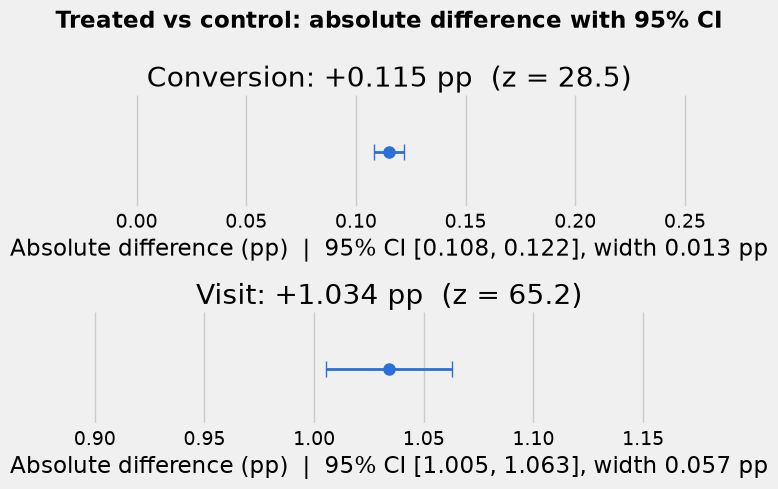

In [9]:
results = []
for name, x in [("Conversion", conv), ("Visit", visits)]:
    z, p = proportions_ztest(x, n, alternative="two-sided")
    lo, hi = confint_proportions_2indep(x[0], n[0], x[1], n[1], compare="diff")
    diff = x[0] / n[0] - x[1] / n[1]
    results.append({"name": name, "diff": diff * 100, "lo": lo * 100, "hi": hi * 100, "z": z})

SPAN = 0.15   # same half-width (pp) for both panels

fig, axes = plt.subplots(2, 1, figsize=(7, 5))
for ax, r in zip(axes, results):
    ax.errorbar(r["diff"], 0,
                xerr=[[r["diff"] - r["lo"]], [r["hi"] - r["diff"]]],
                fmt="o", color="#2a6fdb", capsize=6, lw=2, ms=8)
    ax.set_xlim(r["diff"] - SPAN, r["diff"] + SPAN)       # identical window size
    ax.set_yticks([])
    width = r["hi"] - r["lo"]
    ax.set_title(f'{r["name"]}: +{r["diff"]:.3f} pp  (z = {r["z"]:.1f})')
    ax.set_xlabel(f'Absolute difference (pp)  |  95% CI [{r["lo"]:.3f}, {r["hi"]:.3f}], width {width:.3f} pp')
    ax.spines[["top", "right", "left"]].set_visible(False)

fig.suptitle("Treated vs control: absolute difference with 95% CI", fontweight="bold")
plt.tight_layout(); plt.show()

# Correlation Matrix

- Build the pairwise correlation matrix for numeric features.


In [10]:
corr_matrix = criteo_ad_df.corr(numeric_only=True)

- Plot a lower-triangle correlation heatmap; only label correlations ≥ 0.10.


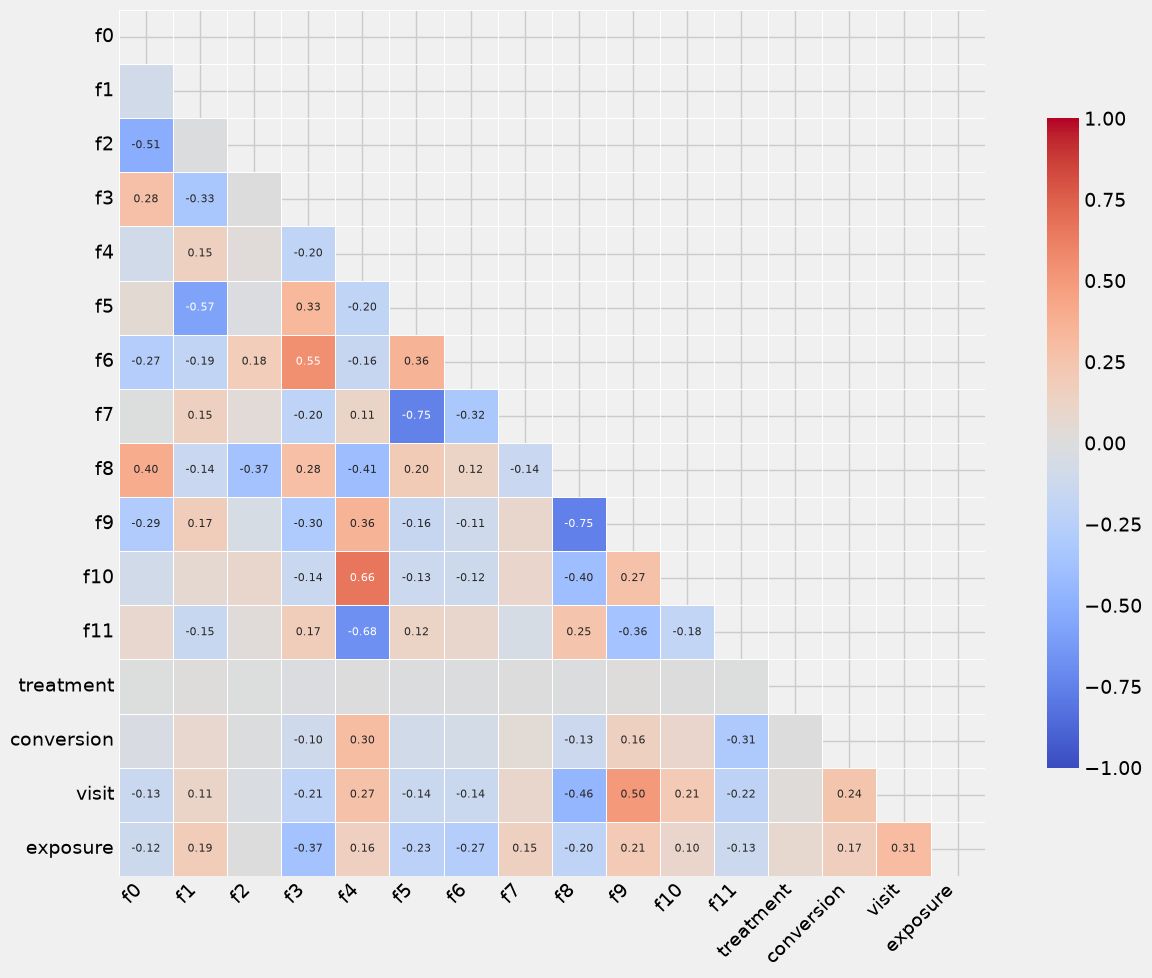

In [11]:
# 4. Generate the visual heatmap with numerical values
labels = corr_matrix.map(lambda v: f"{v:.2f}" if abs(v) >= 0.10 else "")
fig, ax = plt.subplots(figsize=(13, 10), dpi = 100)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

sns.heatmap(
    corr_matrix,
    mask=mask,  # Applies the half-matrix mask
    annot=labels,  # Displays the exact numbers inside each box
    annot_kws={'size': 8},
    fmt="",  # Rounds numbers to 2 decimal places
    cmap="coolwarm",  # Good palette for negative/positive correlations
    vmin=-1,  # Anchors color scale minimum to -1
    vmax=1,  # Anchors color scale maximum to 1
    square=True,  # Forces cells to be perfectly square shapes
    linewidths=0.5,  # Adds a slight line separator between boxes
    ax = ax,
    cbar_kws={"shrink": 0.75},  # Shrinks the color bar slightly to fit well
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
# plt.title("Correlation Matrix (Lower Triangle Half)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Correlation Matrix- Conclusion Remarks
1. Treatment has about 0 correlation with every feature (largest |0.02|), which is consistent with randomization. The balance check below looks at this more closely.
2. Conversion has weak correlation with all features. The largest are f4 (0.30) and f11 (-0.31), and its correlation with every other feature is below 0.20.
3. Exposure and visit relate to the features in the same direction (for example both are negatively correlated with f3), but visit is more strongly tied to f8 (-0.46) and f9 (+0.50). Exposure happens after treatment, so it is not used as a feature.
4. The strongest correlations between features are f5/f7 (-0.75), f8/f9 (-0.75), f4/f11 (-0.68), f4/f10 (+0.66), f1/f5 (-0.57), f3/f6 (+0.55) and f0/f2 (-0.51), so several features carry overlapping information.

# Balance check: treated vs control feature distributions
The correlation matrix cannot catch small imbalances between the arms, so this cell compares treated and control directly, feature by feature.
- `std_mean_diff`: difference in the average feature value between the arms, in standard-deviation units (below about 0.1 is usually treated as balanced).
- `common_value_share`: share of users in each arm who have the feature's most common value, since most features are mostly one value.
- `gap_pp`: treated share minus control share, in percentage points.

In [12]:
FEATURES = [f"f{i}" for i in range(12)]
# Balance check: do treated and control users look alike on each feature?
rows = []
for f in FEATURES:
    t = criteo_ad_df.loc[criteo_ad_df["treatment"] == 1, f]
    c = criteo_ad_df.loc[criteo_ad_df["treatment"] == 0, f]
    smd = (t.mean() - c.mean()) / np.sqrt((t.var() + c.var()) / 2)       # standardized mean difference
    common = criteo_ad_df[f].round(2).mode()[0]                          # most common value of the feature
    share_t = (t.round(2) == common).mean() * 100
    share_c = (c.round(2) == common).mean() * 100
    rows.append({"feature": f,
                 "std_mean_diff": smd,
                 "common_value_share_treated_%": share_t,
                 "common_value_share_control_%": share_c,
                 "gap_pp": share_t - share_c})

balance = pd.DataFrame(rows).set_index("feature")
# with pd.option_context("display.float_format", "{:.3f}".format):
#     print(balance)
print("max |std_mean_diff|:", round(balance["std_mean_diff"].abs().max(), 3))
balance

max |std_mean_diff|: 0.049


,std_mean_diff,common_value_share_treated_%,common_value_share_control_%,gap_pp
feature,,,,
f0,-0.01,26.46,27.30,-0.84
f1,0.02,98.73,99.00,-0.27
f2,-0.01,52.29,52.58,-0.29
f3,-0.05,81.66,83.03,-1.38
f4,0.01,95.62,95.86,-0.24
f5,-0.03,94.60,95.21,-0.61
f6,-0.04,26.37,27.27,-0.90
f7,0.02,94.61,95.21,-0.61
f8,-0.02,52.20,52.49,-0.30


### Balance check - remarks
Overall, groups are balanced on average, with small shift of non common values, explored in detail below.
1. Average feature values are balanced: the largest standardized difference is 0.049 (f3), well below 0.1.
2. The share of users with the common value is lower in the treated arm for all 12 features, by 0.09 pp (f11) to 1.38 pp (f3), so treated users are slightly more likely to have non-common values.
3. This matches the f4 tail: 4.38% of treated users against 4.14% of control users. The tail group converts far more, so this gap likely makes the raw average uplift slightly too high. Adjusting for the f4 groups gives about +0.107 pp against the raw +0.115 pp (computed in the f4 section below).
4. The shift is small, but it qualifies the earlier correlation remark: average values are balanced, with a small shift toward non-common values in the treated arm.

# Check top value share, unique value to understand value count density per features.


         unique  top_value  top_value_share_pct    min  median   max
feature                                                             
f1           60      10.06                98.80  10.06   10.06 16.34
f11         136      -0.17                98.60  -1.38   -0.17 -0.17
f4          260      10.28                95.70  10.28   10.28 21.12
f10       11735       5.30                95.70   5.30    5.30  6.47
f5          132       4.12                94.70  -9.01    4.12  4.12
f7        69058       4.83                94.70   4.83    4.83 12.00
f3          552       4.68                81.90  -8.40    4.68  4.68
f9         1594      13.19                79.50  13.19   13.19 75.30
f2         8377       8.21                52.30   8.21    8.21  9.05
f8         1461       3.97                52.20   3.64    3.97  3.97
f0       141286      12.62                26.50  12.62   21.92 26.75
f6         1645       0.29                26.50 -31.43   -2.41  0.29


Text(0.5, 1.0, 'Top value share for each feature')

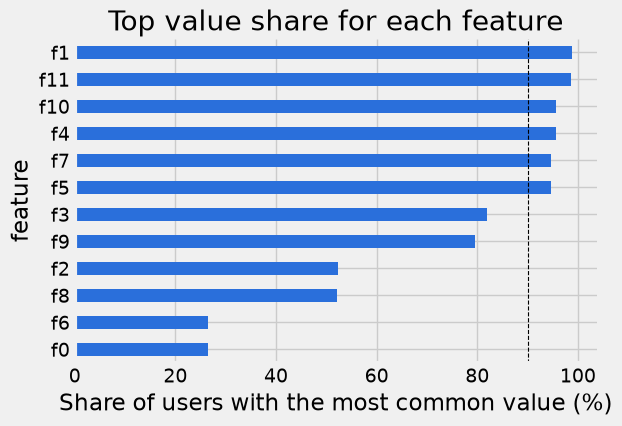

In [13]:
def feature_structure(df, features, decimals=4):
    rows = []
    for f in features:
        vals = df[f].round(decimals)
        vc = vals.value_counts(normalize=True)
        rows.append({
            "feature": f,
            "unique": vals.nunique(),
            "top_value": vc.index[0],
            "top_value_share_pct": round(vc.iloc[0] * 100, 1),
            "min": vals.min(),
            "median": vals.median(),
            "max": vals.max(),
        })
    return pd.DataFrame(rows).set_index("feature").sort_values('top_value_share_pct', ascending=False)

FEATURES = [f"f{i}" for i in range(12)]
print(feature_structure(criteo_ad_df, FEATURES))

fs = feature_structure(criteo_ad_df, FEATURES, decimals=4).sort_values("top_value_share_pct")
ax = fs["top_value_share_pct"].plot.barh(figsize=(6, 4), color="#2a6fdb")
ax.axvline(90, color="k", ls="--", lw=.8)   # 90% reference line
ax.set_xlabel("Share of users with the most common value (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Top value share for each feature")

Remarks -
1. Six features have a single value shared by more than 90% of users (f1 98.8%, f11 98.6%, f4 95.7%, f10 95.7%, f5 94.7%, f7 94.7%), and f3 (81.9%) and f9 (79.5%) are above 75%. These are near-constant with a tail, so a tree can separate the tail from the common value with one split.
2. The common-value users are the same users across features. Among users with the common value, f4 and f10 overlap almost exactly (95.66% have both, against 95.66% and 95.67% individually), as do f5 and f7 (94.7%) and f0 and f6 (26.5%). This explains why those pairs are correlated, and it looks like a shared default group of users (an inference, the data does not say why).
3. The tail groups are small but informative. The f4 tail is about 4.3% of users (606,897) with 86,735 control users, yet its uplift is +1.55 pp against +0.04 pp for the common group, so leaf-size settings must stay loose enough for a split to reach a group this small.
4. Tree models suit this structure: they tolerate the correlated pairs (f8/f9, f4/f10) and the wide range of f6 (-31.43 to 0.29), because they split on thresholds, not distances. f6 is the exception to the spike pattern, with a top value share of only 26.5%.

# Compare conversion uplift for the most common `f4` value vs everyone else.


In [14]:
df = criteo_ad_df
df["f4_common"] = df["f4"].round(2) == 10.28

grp = df.groupby(["f4_common", "treatment"])["conversion"].agg(n="size", conv="sum").unstack()
n_c, n_t = grp["n"][0], grp["n"][1]
conv_c, conv_t = grp["conv"][0], grp["conv"][1]
rate_c = conv_c / n_c * 100
rate_t = conv_t / n_t * 100

table = pd.DataFrame({
    "Users":           ((n_c + n_t) / len(df) * 100).map("{:.1f}%".format),
    "Users (n)":       (n_c + n_t).map("{:,}".format),
    "Control n":       n_c.map("{:,}".format),
    "Treated n":       n_t.map("{:,}".format),
    "Control conv":    conv_c.map("{:,}".format),
    "Treated conv":    conv_t.map("{:,}".format),
    "Control rate":    rate_c.map("{:.3f}%".format),
    "Treated rate":    rate_t.map("{:.3f}%".format),
    "Absolute uplift": (rate_t - rate_c).map("{:+.2f} pp".format),
    "Relative lift":   ((rate_t / rate_c - 1) * 100).map("{:+.0f}%".format),
})
table.index = table.index.map({False: "f4 tail (non-common)", True: "f4 common"})
table = table.sort_index(ascending=False)

table

,Users,Users (n),Control n,Treated n,Control conv,Treated conv,Control rate,Treated rate,Absolute uplift,Relative lift
f4_common,,,,,,,,,,
f4 tail (non-common),4.3%,"606,897","86,735","520,162","3,117","26,762",3.594%,5.145%,+1.55 pp,+43%
f4 common,95.7%,"13,372,695","2,010,202","11,362,493",946,"9,949",0.047%,0.088%,+0.04 pp,+86%


### Remarks
Even though about 95.7% of users share the most common f4 value, most conversions come from the small group of users with other (tail) f4 values.
1. The tail group is only 4.3% of users (606,897) but accounts for about 73% of all conversions (29,879 of 40,774).
2. Conversion rates are far higher in the tail group: 3.59% (control) and 5.14% (treated), against 0.047% and 0.088% for users with the common value.
3. The ad's effect is also larger in the tail group in absolute terms (+1.55 pp, against +0.04 pp), but in relative terms the lift is smaller (+43%, against +86%), because the tail group's baseline conversion is already high.

# Uplift adjusted for the f4 groups
The tail group (non-common f4 values) is slightly larger in the treated arm and converts far more, so the raw average uplift is a little too high. This cell compares treated and control inside each f4 group, then combines the two group uplifts using the share of treated users in each group.
- `raw uplift`: treated conversion rate minus control conversion rate over all users.
- `f4-adjusted uplift`: the same difference after accounting for the f4 groups.
- Result: the adjusted uplift is +0.107 pp against the raw +0.115 pp, so the ad's effect is about 7% smaller than the raw number suggests.

In [15]:
# Uplift adjusted for the f4 groups: compare treated and control inside each f4 group,
# then combine the two group uplifts using the share of treated users in each group
df = criteo_ad_df
df["f4_common"] = df["f4"].round(2) == 10.28

g = df.groupby(["f4_common", "treatment"])["conversion"].agg(["mean", "size"]).unstack()
group_uplift = g["mean"][1] - g["mean"][0]                  # uplift inside each f4 group
weights = g["size"][1] / g["size"][1].sum()                 # share of treated users in each group
adjusted = (group_uplift * weights).sum() * 100

raw = (df.loc[df["treatment"] == 1, "conversion"].mean()
       - df.loc[df["treatment"] == 0, "conversion"].mean()) * 100
print(f"raw uplift: {raw:.3f} pp | f4-adjusted uplift: {adjusted:.3f} pp")

raw uplift: 0.115 pp | f4-adjusted uplift: 0.107 pp


# Treatment, Visit, Conversion analysis

- Same conversion breakdown, split by treatment arm.


In [16]:
total_row_count = criteo_ad_df.shape[0]
overall_conversion = criteo_ad_df.groupby(['conversion','treatment'])['visit'].count().to_frame('overall_conversion_count').reset_index()
# overall_conversion
conversion_if_visited = criteo_ad_df.loc[(criteo_ad_df['visit'] == 1)].groupby(['conversion','treatment'])['visit'].count().to_frame('visited_conversion_count').reset_index()
conversion_details = pd.merge(overall_conversion, conversion_if_visited, on=['conversion','treatment'], how='left')
conversion_details['overall_conversion_rate_percentage'] = 100*conversion_details['visited_conversion_count'] / total_row_count
# conversion_details

treatment_total = conversion_details.groupby('treatment')['overall_conversion_count'].transform('sum')
conversion_details['conversion_rate_percentage_per_treatment'] = (
    100 * conversion_details['overall_conversion_count'] / treatment_total
)
conversion_details

# conversion_if_visited

,conversion,treatment,overall_conversion_count,visited_conversion_count,overall_conversion_rate_percentage,conversion_rate_percentage_per_treatment
0,0,0,2092874,76042,0.54,99.81
1,0,1,11845944,540113,3.86,99.69
2,1,0,4063,4063,0.03,0.19
3,1,1,36711,36711,0.26,0.31


In [17]:
arm = conversion_details.groupby('treatment').agg(
    n=("overall_conversion_count", "sum"),
    visits=("visited_conversion_count", "sum"),
)
arm["conversions"] = conversion_details[conversion_details.conversion == 1].groupby("treatment")["overall_conversion_count"].sum()
arm["visit_rate"] = arm.visits / arm.n * 100
arm["conv_rate"] = arm.conversions / arm.n * 100
arm.index = arm.index.map({0: "Control", 1: "Treated"})
arm

,n,visits,conversions,visit_rate,conv_rate
treatment,,,,,
Control,2096937,80105,4063,3.82,0.19
Treated,11882655,576824,36711,4.85,0.31


# Conversion and visit rate per Treatment group
- We see increase of both the target metrics in Treated vs Control groups.
- Below is Bar chart: visit rate and conversion rate for control vs treated to show it visually

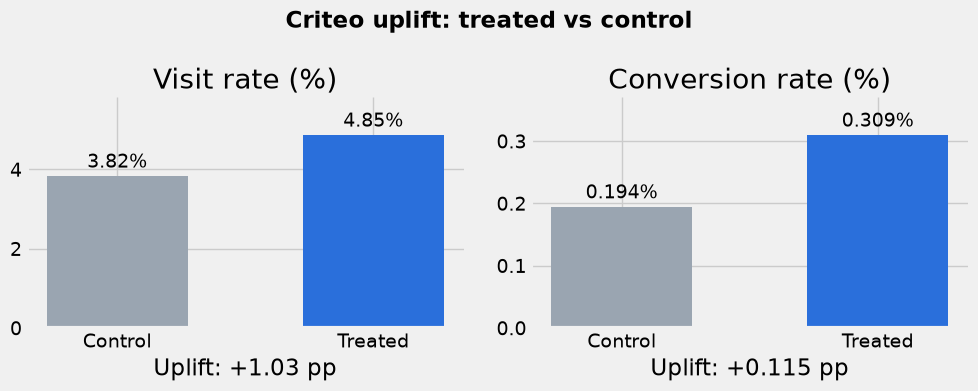

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#9aa5b1", "#2a6fdb"]

for ax, col, title, fmt in [
    (axes[0], "visit_rate", "Visit rate (%)", "{:.2f}%"),
    (axes[1], "conv_rate", "Conversion rate (%)", "{:.3f}%"),
]:
    bars = ax.bar(arm.index, arm[col], color=colors, width=0.55)
    ax.bar_label(bars, labels=[fmt.format(v) for v in arm[col]], padding=3)
    ax.set_title(title)
    ax.set_ylim(0, arm[col].max() * 1.2)
    ax.spines[["top", "right"]].set_visible(False)

lift_v = arm.visit_rate["Treated"] - arm.visit_rate["Control"]
lift_c = arm.conv_rate["Treated"] - arm.conv_rate["Control"]
axes[0].set_xlabel(f"Uplift: +{lift_v:.2f} pp")
axes[1].set_xlabel(f"Uplift: +{lift_c:.3f} pp")

fig.suptitle("Criteo uplift: treated vs control", fontweight="bold")
plt.tight_layout()
plt.show()

- Counts of rows, visits, and conversions by treatment arm.


In [19]:
# row count, visited count, converted count by treatment
criteo_ad_df.groupby('treatment').agg(
    total_rows=('conversion', 'size'),
    visited_count=('visit', 'sum'),
    converted_count=('conversion', 'sum')
).reset_index()

,treatment,total_rows,visited_count,converted_count
0,0,2096937,80105,4063
1,1,11882655,576824,36711


Remarks on data for our uplift modeling - 
1. Treatment column will be dropped since its not part of feature set, nor a Target. We will use this to split the datset for uplift modelling.
2. We have 2 target columns - Visits is more dense and has lot of values; Conversion - Might be more business relevant than Visits but is very sparse

The Plan - 
1. Conversion is our primary business relevant target, our uplift modelling will be targeting this
2. We will build 3 models - 
    1. T learner - Baseline model
    2. X learner Version 1
    3. X learner version 2
        Version 2 x learner will have max depth of 3, fewer trees 150, lower learning rate of 0.03 - more regularized effect learner

Difference in both X learners are change in hyper parameters (more pruned trees in version 2). <br>
Decile level comparison and Qini Curve comparison of all 3 models to evaluate the uplift for each.

# Uplift Modelling

## Train Test split

- Define feature list, target (`conversion`), and random seed.

In [20]:
FEATURES = [f"f{i}" for i in range(12)]
TARGET = "conversion"
SEED = 42

In [21]:
# ---- 1. Split all users: 75% train pool / 25% test ----
strata = criteo_ad_df["treatment"].astype(str) + "_" + criteo_ad_df["conversion"].astype(str)

train_df, test_df = train_test_split(
    criteo_ad_df, test_size=0.25, stratify=strata, random_state=SEED
)

In [22]:
# ---- 2. Split the train pool into fit (model training) and validation (tuning, early stopping) ----
strata_train = train_df["treatment"].astype(str) + "_" + train_df["conversion"].astype(str)

In [23]:
fit_df, val_df = train_test_split(
    train_df, test_size=0.20, stratify=strata_train, random_state=SEED
)

for name, d in [("fit", fit_df), ("val", val_df), ("test", test_df)]:
    print(name, len(d), "treated share:", round(d.treatment.mean(), 3),
          "conv rate %:", round(d.conversion.mean() * 100, 3))

fit 8387755 treated share: 0.85 conv rate %: 0.292
val 2096939 treated share: 0.85 conv rate %: 0.292
test 3494898 treated share: 0.85 conv rate %: 0.292


- Helper to pull `X`, `y`, and treatment arrays from a dataframe.

In [24]:
def arrays(df):
    return df[FEATURES].values, df[TARGET].values, df["treatment"].values

In [25]:
X_fit, y_fit, w_fit = arrays(fit_df)
X_val, y_val, w_val = arrays(val_df)
X_te,  y_te,  w_te  = arrays(test_df)
arm_fit = np.where(w_fit == 1, "treated", "control")
p_fit = w_fit.mean()

p_fit is average of w_fit which is essentially Treated or Controlled. <br>
85% treated, 15% Control. <br>
This propensity score is passed to X learner.

Scalable code to make sure all the other models are also running on same sets for better comparison. Now, we have validation set as well.

- Helper: compute a single Qini score from `y`, `w`, and uplift scores.


In [26]:
def qini_of(y, w, s):
    d = pd.DataFrame({"y": y, "w": w, "s": s})
    return qini_score(d, outcome_col="y", treatment_col="w")["s"]

- Shared XGBoost defaults; override kwargs per model version.


In [27]:
# ---- Model builders: shared defaults, override per version ----
BASE = dict(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=SEED)
def clf(**kw): return XGBClassifier(**{**BASE, **kw})
def reg(**kw): return XGBRegressor(**{**BASE, **kw})

- Logger: store validation and test Qini for each version.


In [28]:
# ---- Logging ----
results = []        # one row per version
test_scores = {}    # uplift scores on test, kept for decile / cumulative tables later

def log(version, change, s_val, s_te):
    results.append({"version": version, "change": change,
                    "val_qini": qini_of(y_val, w_val, s_val),
                    "test_qini": qini_of(y_te, w_te, s_te)})
    test_scores[version] = s_te
    print(pd.DataFrame(results).tail(1).to_string(index=False))

- Runner: fit a T-learner and log Qini on val + test.


In [29]:
# ---- Runners ----
def run_t(version, change, clf_kw=None):
    m = BaseTClassifier(learner=clf(**(clf_kw or {})), control_name="control")
    m.fit(X=X_fit, treatment=arm_fit, y=y_fit)
    log(version, change, m.predict(X=X_val).ravel(), m.predict(X=X_te).ravel())

- Runner: fit an X-learner and log Qini on val + test.


In [30]:
def run_x(version, change, clf_kw=None, reg_kw=None):
    m = BaseXClassifier(outcome_learner=clf(**(clf_kw or {})),
                        effect_learner=reg(**(reg_kw or {})), control_name="control")
    m.fit(X=X_fit, treatment=arm_fit, y=y_fit, p=np.full(len(X_fit), p_fit))
    pv = np.full(len(X_val), p_fit); pt = np.full(len(X_te), p_fit)
    log(version, change, m.predict(X=X_val, p=pv).ravel(), m.predict(X=X_te, p=pt).ravel())

- Train T-v1, X-v1, and regularized X-v2; show the results table.


In [31]:
# ---- Versions ----
run_t("T-v1", "baseline")
run_x("X-v1", "default settings")
run_x("X-v2", "shallow, regularized effect learner",
      reg_kw=dict(n_estimators=150, max_depth=3, learning_rate=0.03,
                  min_child_weight=200, reg_lambda=10))                 

pd.DataFrame(results)

version   change  val_qini  test_qini
   T-v1 baseline      0.31       0.38
version           change  val_qini  test_qini
   X-v1 default settings      0.39       0.35
version                              change  val_qini  test_qini
   X-v2 shallow, regularized effect learner      0.40       0.39


,version,change,val_qini,test_qini
0,T-v1,baseline,0.31,0.38
1,X-v1,default settings,0.39,0.35
2,X-v2,"shallow, regularized effect learner",0.40,0.39


1. X-v1 beat T-v1 on validation (0.39 vs 0.31), but T-v1 beat X-v1 on test (0.38 vs 0.35), so the order of these two models flips between the two sets.
2. T-v1 scored 0.07 higher on test than on validation, and X-v1 scored 0.04 lower, so the scores for both models move noticeably from one set to the other.
3. X-v2 scored highest on validation (0.40) and on test (0.39), and its two scores are within 0.01 of each other, so it is the most consistent of the three.
4. The Qini score is a single number, and gaps of 0.01 to 0.04 between models are small, so we check below whether they are real.

Creating a dataframe to store actual vs predicted outcomes for all test users
- y is actual outcome: 0 or 1
- w is actual arm: Control or treatment, 0/1
- T-v1, X-v1, X-v2 are predicted uplift values for each of the test users by the individual model.

In [32]:
cmp_df = pd.DataFrame({"y": y_te, "w": w_te,
                       "T-v1": test_scores["T-v1"],
                       "X-v1": test_scores["X-v1"],
                       "X-v2": test_scores["X-v2"]
                       })
cmp_df.head()                       

,y,w,T-v1,X-v1,X-v2
0,0,1,0.00,0.00,0.00
1,0,0,0.00,0.00,0.00
2,0,1,0.00,0.00,0.00
3,0,1,0.00,0.00,0.00
4,0,1,0.00,0.00,0.00


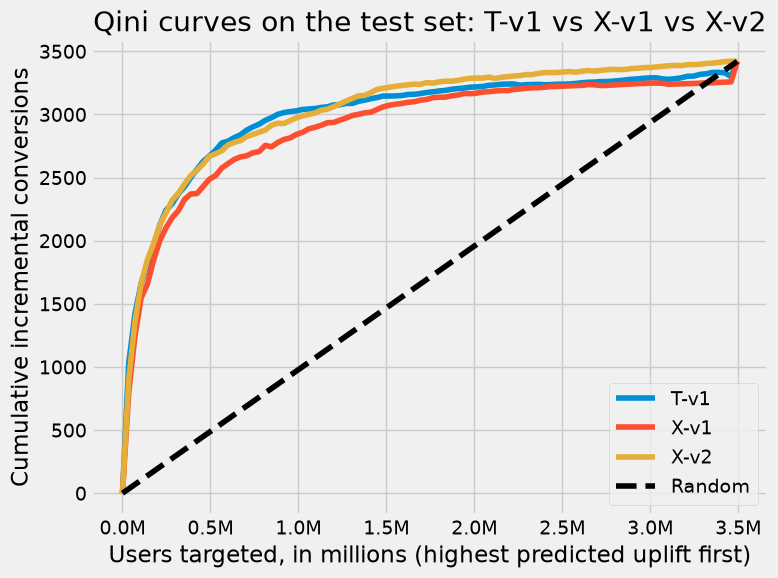

In [33]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 6))
plot_qini(cmp_df, outcome_col="y", treatment_col="w", ax=ax)
ax.set_title("Qini curves on the test set: T-v1 vs X-v1 vs X-v2")
ax.set_xlabel("Users targeted, in millions (highest predicted uplift first)")
ax.set_ylabel("Cumulative incremental conversions")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))   # 0.5M, 1.0M ... instead of 1e6 offset
plt.tight_layout(); plt.show()

### Qini curve - remarks
1. All three curves rise steeply at the start and flatten after about 1M users (roughly 30% of the 3.5M test users), by which point each has captured about 3,000 of the roughly 3,420 total extra conversions. The random-targeting line (dashed) stays far below them throughout.
2. T-v1 and X-v2 almost overlap up to about 1M users and stay close afterwards, with X-v2 slightly above T-v1 beyond about 1.5M users. X-v1 sits below both between roughly 0.3M and 1.5M users, which matches its lower test Qini score (0.35 against 0.38 and 0.39).
3. All curves end at the same point, because targeting every user gives the same total effect whatever the ranking. T-v1 and X-v1 jump up at the very end (the lowest-ranked users still show a small positive effect), while X-v2 rises more smoothly.
4. The curves show the same pattern as the decile table: nearly all the benefit sits at the start of the ranking, and the models differ only slightly.

## Decile table to see each slice in isolation

In [34]:
def decile_uplift(df, score, q=10):
    d = df[["y", "w", score]].copy()
    d["decile"] = pd.qcut(d[score].rank(method="first"), q, labels=False)   # 9 = highest predicted uplift
    g = d.groupby(["decile", "w"])["y"].mean().unstack() * 100
    # print(g)
    return g[1] - g[0]                                                       # actual uplift in pp

models = ["T-v1", "X-v1", "X-v2"]
dec = pd.DataFrame({m: decile_uplift(cmp_df, m) for m in models}).sort_index(ascending=False)
dec.index.name = "decile (9 = top)"

with pd.option_context("display.float_format", "{:+.3f}".format):
    print(dec)

                   T-v1   X-v1   X-v2
decile (9 = top)                     
9                +0.804 +0.770 +0.813
8                +0.067 +0.038 +0.049
7                +0.022 +0.041 +0.024
6                +0.007 +0.021 +0.030
5                +0.010 +0.014 +0.012
4                +0.009 +0.012 +0.003
3                -0.001 +0.008 +0.008
2                +0.006 -0.000 +0.005
1                +0.004 +0.003 +0.006
0                +0.049 +0.061 +0.011


### Decile - explanation
1. Ranking: Sort all test users from highest to lowest predicted uplift, then split them into 10 equal groups (decile). Decile 9 holds the users the model thinks the ad helps the most.
2. Group by: within each decile, split users into control and treated, then average their actual conversion (0 or 1) to get the real conversion rate for each arm.
3. Subtraction: subtract treated conversion and control conversion to get the uplift for each of those deciles.

Deciles are ranked based on predicted uplift values and values you see are actual uplifts.

### Decile results - remarks
1. Decile 9 (the users each model ranks highest) has an actual uplift of +0.77 to +0.81 pp for all three models (T-v1 +0.80, X-v1 +0.77, X-v2 +0.81), about 7x the overall +0.115 pp.
2. Decile 8 is much smaller (+0.04 to +0.07 pp) and deciles 0 to 7 stay between -0.001 and +0.061 pp, so the effect is concentrated in the top decile.
3. The gap between models in decile 9 is at most 0.04 pp, which is small compared with the noise in a single decile, so the decile table does not separate the models.
4. Small differences in the low deciles (for example decile 7 vs decile 6) are too small to read as ranking errors, because each rests on few conversions.
5. Decile 0 is ranked lowest by every model, but X-v1 shows a clearly higher actual uplift there (+0.061 pp) than the deciles just above it. T-v1 (+0.049 pp) is too uncertain to say (see the confidence intervals below), and X-v2 shows only +0.011 pp.

## Decile uplift with confidence intervals
The decile table gives one number per decile, but the lower deciles rest on very few conversions. This plot adds a 95% confidence interval to each decile's actual uplift, so we can see which differences are real.
- Dots are the actual uplift (treated rate minus control rate) in that decile, and the bars are the 95% confidence interval.
- The top chart shows all deciles. The bottom chart zooms into deciles 0 to 8, because decile 9 is much larger than the rest.
- A bar that crosses the dashed zero line means that decile's uplift cannot be told apart from zero.

         T-v1                 X-v1                 X-v2              
       uplift     lo     hi uplift     lo     hi uplift     lo     hi
decile                                                               
9      +0.804 +0.682 +0.925 +0.770 +0.643 +0.898 +0.813 +0.682 +0.945
8      +0.067 +0.034 +0.100 +0.038 -0.001 +0.077 +0.049 +0.010 +0.088
7      +0.022 +0.004 +0.039 +0.041 +0.017 +0.065 +0.024 +0.000 +0.047
6      +0.007 -0.005 +0.018 +0.021 +0.008 +0.035 +0.030 +0.016 +0.043
5      +0.010 +0.001 +0.019 +0.014 +0.001 +0.026 +0.012 +0.002 +0.022
4      +0.009 +0.004 +0.015 +0.012 +0.003 +0.022 +0.003 -0.006 +0.012
3      -0.001 -0.008 +0.006 +0.008 +0.002 +0.013 +0.008 +0.002 +0.015
2      +0.006 +0.004 +0.009 -0.000 -0.008 +0.008 +0.005 -0.003 +0.014
1      +0.004 -0.003 +0.011 +0.003 -0.002 +0.007 +0.006 -0.000 +0.013
0      +0.049 -0.010 +0.109 +0.061 +0.026 +0.095 +0.011 -0.004 +0.027


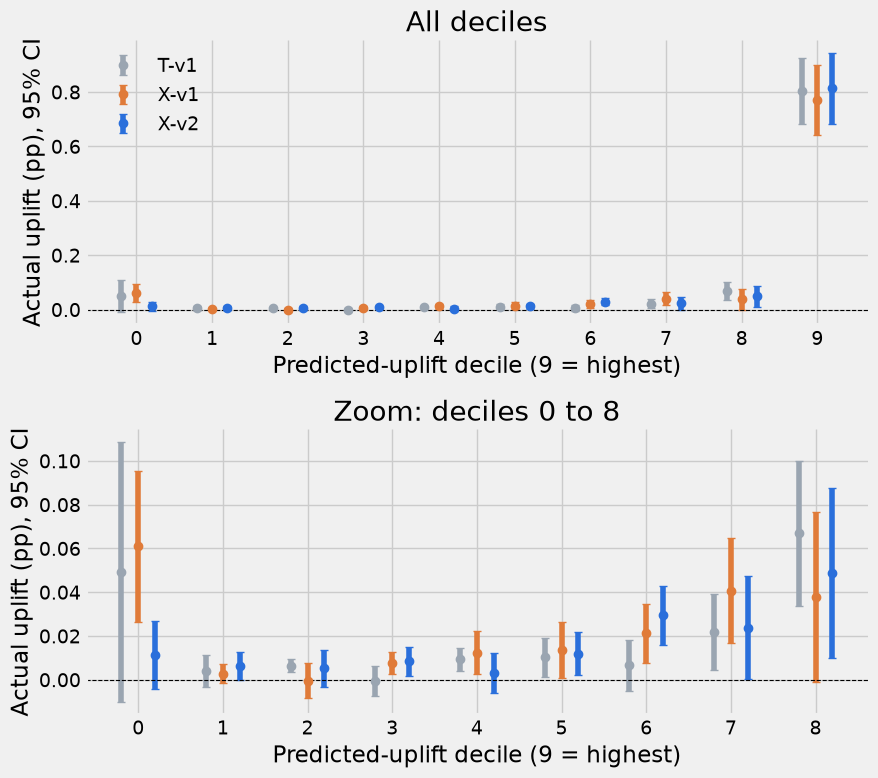

In [35]:
# Decile uplift with 95% confidence intervals, for all three models
def decile_uplift_ci(df, score, q=10):
    d = df[["y", "w", score]].copy()
    d["decile"] = pd.qcut(d[score].rank(method="first"), q, labels=False)    # 9 = highest predicted uplift
    g = d.groupby(["decile", "w"])["y"].agg(["mean", "size"]).unstack()
    p1, p0 = g["mean"][1], g["mean"][0]                                      # treated / control conversion rate
    n1, n0 = g["size"][1], g["size"][0]
    uplift = (p1 - p0) * 100                                                 # actual uplift in pp
    se = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0) * 100              # standard error in pp
    return pd.DataFrame({"uplift": uplift, "lo": uplift - 1.96 * se, "hi": uplift + 1.96 * se})

models = ["T-v1", "X-v1", "X-v2"]
colors = ["#9aa5b1", "#e07b39", "#2a6fdb"]
ci = {m: decile_uplift_ci(cmp_df, m) for m in models}

with pd.option_context("display.float_format", "{:+.3f}".format):
    print(pd.concat(ci, axis=1).sort_index(ascending=False))

fig, axes = plt.subplots(2, 1, figsize=(9, 8))
for ax, deciles, title in [(axes[0], list(range(10)), "All deciles"),
                           (axes[1], list(range(9)), "Zoom: deciles 0 to 8")]:
    for k, (m, c) in enumerate(zip(models, colors)):
        r = ci[m].loc[deciles]
        x = np.array(deciles) + (k - 1) * 0.2                                # offset so the models do not overlap
        ax.errorbar(x, r["uplift"], yerr=[r["uplift"] - r["lo"], r["hi"] - r["uplift"]],
                    fmt="o", color=c, capsize=3, label=m)
    ax.axhline(0, color="k", ls="--", lw=.8)
    ax.set_title(title)
    ax.set_xlabel("Predicted-uplift decile (9 = highest)")
    ax.set_ylabel("Actual uplift (pp), 95% CI")
    ax.set_xticks(deciles)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

### Decile confidence intervals - remarks
1. Decile 9 is clearly above zero for all three models (T-v1 +0.80 pp, 95% CI 0.68 to 0.93; X-v1 +0.77, 0.64 to 0.90; X-v2 +0.81, 0.68 to 0.95). The intervals overlap almost completely, so the models do not differ at the top.
2. Decile 8 is small (+0.04 to +0.07 pp) and the model intervals overlap there too. Deciles 1 to 7 are all at most +0.04 pp, about 5% of decile 9.
3. Many lower-decile intervals are narrow (mostly within ±0.02 pp) and sit just above zero, which fits a small positive effect for most users. Several still cross zero (for example T-v1 in deciles 6, 3 and 1, and X-v2 in deciles 4 and 2), so the order of deciles 1 to 7 should not be read as a ranking.
4. Decile 0, which every model ranks lowest, is clearly above zero only for X-v1 (+0.061, CI 0.026 to 0.095). The T-v1 interval is wide and includes zero (+0.049, CI -0.010 to 0.109), and X-v2 is about zero (+0.011, CI -0.004 to 0.027), so X-v2 shows no sign of the bottom-decile mis-ranking.
5. Overall, the effect is concentrated in decile 9, where the three models are indistinguishable, and the models differ only in small lower-decile details.

# Bootstrap on test scores: T-v1 vs X-v1 vs X-v2
- Bootstrap Qini gaps between T-v1, X-v1, and X-v2 on the test set.

In [ ]:
# rng = np.random.default_rng(SEED)
# rows = []
# for _ in range(500):
#     idx = rng.integers(0, len(cmp_df), len(cmp_df))
#     s = qini_score(cmp_df.iloc[idx], outcome_col="y", treatment_col="w")
#     rows.append({"X-v1 - T-v1": s["X-v1"] - s["T-v1"],
#                  "X-v2 - T-v1": s["X-v2"] - s["T-v1"],
#                  "X-v2 - X-v1": s["X-v2"] - s["X-v1"]
#                  })

# boot = pd.DataFrame(rows)
# print(boot.mean())
# print(boot.quantile([0.025, 0.975]))

X-v1 - T-v1   -0.03
X-v2 - T-v1    0.01
X-v2 - X-v1    0.04
dtype: float64
      X-v1 - T-v1  X-v2 - T-v1  X-v2 - X-v1
0.03        -0.08        -0.04         0.01
0.97         0.02         0.06         0.07


### Bootstrap on test scores: what it does
- Take the test users and randomly pick the same number of users from them, with replacement, so some users appear twice and some not at all.
- Calculate the Qini score of each model (T-v1, X-v1, X-v2) on that resampled set, then find the gap between each pair of models.
- Repeat this 500 times, which gives 500 gaps per pair and shows how much the gap changes just from which users happen to be in the sample.
- Report the average gap and the range that covers the middle 95% of the 500 gaps.

### Interpretation
- If the range includes 0, the gap could be just luck, so we can't say one model is better.
- If the range stays above or below 0, the gap is consistent across resamples, so the difference is real.
- X-v1 − T-v1 (-0.03, range -0.08 to +0.02) and X-v2 − T-v1 (+0.01, range -0.04 to +0.06) both include 0, so neither X-learner is clearly better than the T-learner.
- X-v2 − X-v1 (+0.04, range +0.01 to +0.07) stays above 0, so the regularized X-learner is better than the default X-learner.

- Cumulative extra conversions caused by the ad at each targeting cutoff (top 10% to 40% of users by predicted uplift), for each model.

In [37]:
def cutoff_summary(df, score, cutoffs=(0.1, 0.2, 0.3, 0.4)):
    d = df.sort_values(score, ascending=False).reset_index(drop=True)
    w, y = d["w"].values, d["y"].values
    n = len(d)
    n_t, n_c = np.cumsum(w == 1), np.cumsum(w == 0)
    y_t, y_c = np.cumsum(y * (w == 1)), np.cumsum(y * (w == 0))
    total_inc = y_t[-1] - y_c[-1] * n_t[-1] / n_c[-1]          # benefit of treating everyone

    rows = []
    for c in cutoffs:
        k = int(c * n) - 1
        inc = y_t[k] - y_c[k] * n_t[k] / n_c[k]                # extra conversions caused by the ad
        rows.append({"model": score,
                     "targeted": f"top {int(c*100)}%",
                     "users_targeted": k + 1,
                     "all_conversions": int(y_t[k] + y_c[k]),   # every conversion in this group
                     "incremental_conv": round(inc),
                     "share_of_total_benefit_%": round(inc / total_inc * 100, 1)})
    out = pd.DataFrame(rows)
    out["added_by_this_step"] = out["incremental_conv"].diff().fillna(out["incremental_conv"]).round()
    return out
models = ["X-v2", "T-v1"] #, "X-v1", ]
summary = pd.concat([cutoff_summary(cmp_df, m) for m in models], ignore_index=True)
print(summary.to_string(index=False))

model targeted  users_targeted  all_conversions  incremental_conv  share_of_total_benefit_%  added_by_this_step
 X-v2  top 10%          349489             8691              2452                     71.70             2452.00
 X-v2  top 20%          698979             9418              2827                     82.60              375.00
 X-v2  top 30%         1048469             9697              3000                     87.70              173.00
 X-v2  top 40%         1397959             9846              3164                     92.50              164.00
 T-v1  top 10%          349489             7613              2428                     71.00             2428.00
 T-v1  top 20%          698979             8218              2869                     83.90              441.00
 T-v1  top 30%         1048469             8394              3040                     88.90              171.00
 T-v1  top 40%         1397959             8466              3120                     91.20             

### Targeting cutoff - remarks
1. Targeting the top 10% of test users (349,489) gives about 72% of the ad's total extra conversions for X-v2 (2,452) and 71% for T-v1 (2,428).
2. The top 20% (698,979 users) gives about 83% for X-v2 (2,827 extra conversions) and 84% for T-v1 (2,869).
3. Each further 10% adds less: for X-v2 the extra conversions are +375 (10% to 20%), +173 (20% to 30%) and +164 (30% to 40%).
4. T-v1 and X-v2 give nearly the same numbers at every cutoff, in line with the Qini and bootstrap results.

# Overall Conclusion

- Data: We used 13.98M users, 85% shown the ad and 15% not, with no missing values, and conversion is rare at about 3 in 1,000 users.<br>


- Features: Most of the 12 anonymous features are near-constant, with 90%+ of users sharing one value and a small tail of different values.
- Experiment check: Average feature values are balanced between treated and control (largest standardized difference 0.049), with a small shift toward non-common values in the treated arm, which lowers the average uplift slightly from +0.115 pp to about +0.107 pp.
- Overall result: The ad works on average, raising conversion from 0.19% to 0.31% (+0.115 pp, about +59%) and visits from 3.8% to 4.9%.
- Significance: Both lifts are statistically significant (p < 0.001) with narrow confidence intervals.
- Who responds: The ad's effect is concentrated, as shown by the f4 tail users (4% of users), who gain +1.55 pp against +0.04 pp for everyone else.
- Setup: We split users into 60% training, 15% validation and 25% test, keeping the treated/control mix the same in each, and predicted conversion.
- Models: We compared three: a simple T-learner baseline, an X-learner with default settings and a more regularized X-learner (X-v2).
- Scores: On the Qini score (higher is better), the test results are T-v1 0.38, X-v1 0.35 and X-v2 0.39, and X-v2 is the most consistent between validation and test.
- Decile results: All three models find a top 10% group where the ad adds about +0.8 pp, roughly 7× the average, and the lower deciles are near zero.
- Model comparison: The bootstrap shows X-v2 is better than X-v1 (+0.04, range +0.01 to +0.07), but neither X-learner is clearly better than the T-learner, since both of those ranges include zero.

## Business meaning:
The ad's benefit is concentrated in a small group of users. The top 20% of users by predicted uplift (about 699k test users) give about 83% of the total extra conversions (2,827). The next 20% adds only 337 more for another 699k users, about 8× fewer per user, so the top 20% is the recommended starting cutoff. The final cutoff depends on the ad cost per user and the value of a conversion, which we don't have.

## Next steps:
Use the ad cost per user and the value of a conversion to choose the final targeting cutoff, then confirm it with a follow-up experiment that shows the ad only to the top-ranked users.